# Problem Statement



<html> <font color = Darkblue>
The purpose is to predict whether the Pima Indian women shows signs of diabetes or not. We are using a dataset collected by "National Institute of Diabetes and Digestive and Kidney Diseases" which consists of a number of attributes which would help us to perform this prediction.
</font>
</html>

<html>
<font color = blue>
<b>Constraints on data collection </b>

</font>
</html>

<html> <font color = Darkblue>
All patients whose data has been collected are females at least 21 years old of Pima Indian heritage
</font>
</html>

In [32]:
#Import all the necessary modules
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt   
import seaborn as sns
%matplotlib inline 

In [33]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Q1. Load the PIMA Indian Diabetes file into Python DataFrame. 


The file can be accessed directly from the URL (https://archive.ics.uci.edu/ml/machine-learning-databases/pima-indians-diabetes/pima-indians-diabetes.data or you may first download it to a local folder and then load it into Python dataframe.  Let us assume the data frame is named pima_df


In [34]:
colnames = ['preg', 'glu', 'bp', 'sft', 'ins', 'bmi', 'dpf', 'age', 'outcome']
df = pd.read_csv("pima-indians-diabetes.data",names=colnames)
df.head()

,preg,glu,bp,sft,ins,bmi,dpf,age,outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [35]:
df.describe()

,preg,glu,bp,sft,ins,bmi,dpf,age,outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


It is always a good practice to eye-ball raw data to get a feel of the data in terms of number of structure of the file, number of attributes, types of attributes and a general idea of likely challenges in the dataset. You would notice that it is a comma separated file. There are no column names!. Check the associated folders and find out about each attribute the name. What information is available about the data.

# Q2. Print 10 samples from the dataset

In [36]:
df.head(10)

,preg,glu,bp,sft,ins,bmi,dpf,age,outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


# Q3 Print the datatypes of each column and the shape of the dataset 

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
preg       768 non-null int64
glu        768 non-null int64
bp         768 non-null int64
sft        768 non-null int64
ins        768 non-null int64
bmi        768 non-null float64
dpf        768 non-null float64
age        768 non-null int64
outcome    768 non-null int64
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [38]:
df.shape

(768, 9)

There are '0's in the data. Are they really valid '0's or they are missing values?
Plasma, BP, skin thickness etc. these values cannot be 0.
look at column by column logically to understand this.


# Q4 Replace all the 0s in the column with the median of the same column value accordingly.

In [40]:
cols = list(df.columns)
cols.remove('outcome')
for col in cols:
    df[col]=df[col].replace(0,df[col].mean())

# Q5 Print the descriptive statistics of each & every column using describe() function

In [41]:
df.describe()

,preg,glu,bp,sft,ins,bmi,dpf,age,outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,4.400782,121.681605,72.254807,26.606479,118.660163,32.450805,0.471876,33.240885,0.348958
std,2.984162,30.436016,12.115932,9.631241,93.080358,6.875374,0.331329,11.760232,0.476951
min,1.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,2.000000,99.750000,64.000000,20.536458,79.799479,27.500000,0.243750,24.000000,0.000000
50%,3.845052,117.000000,72.000000,23.000000,79.799479,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Q6 See the distribution of 'Class' variable and plot it using appropriate graph.

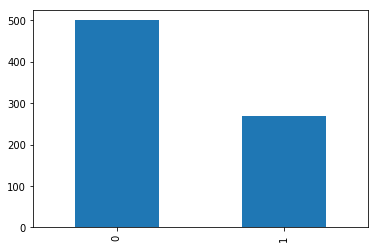

In [42]:
df['outcome'].value_counts().plot(kind='bar')

#Just for your understanding - Using univariate analysis check the individual attributes for their basic statistic such as central values, spread, tails etc. What are your observations (any two attributes). Its an optional step and will not be graded.

# BP

count    768.000000
mean      72.254807
std       12.115932
min       24.000000
25%       64.000000
50%       72.000000
75%       80.000000
max      122.000000
Name: bp, dtype: float64
Std= 12.115931598253855


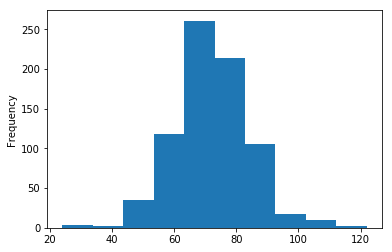

In [10]:
print(df.bp.describe())
print("Std=",df.bp.std())
df.bp.plot(kind="hist")

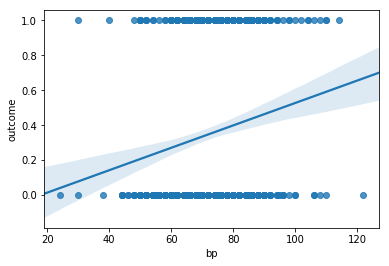

In [11]:
sns.regplot(x='bp',y='outcome', data=df)

## Observations
- BP seems to be a more or less normal distribution centered arround 72 
- Sample or population seems to be left skewed, which is inferable. We have lesses people close to 0 value and more towards 100s.
- Mean and Median for the distribution is same, BP features seems to be a good representation of population.
- From regplot, seems like BP is not a good predictor of outcome

# Q7. Use pairplots and correlation method to observe the relationship between different variables and state your insights.
Hint: Use seaborn plot and check the relationship between different variables 


Using the plot - infer the relationship between different variables

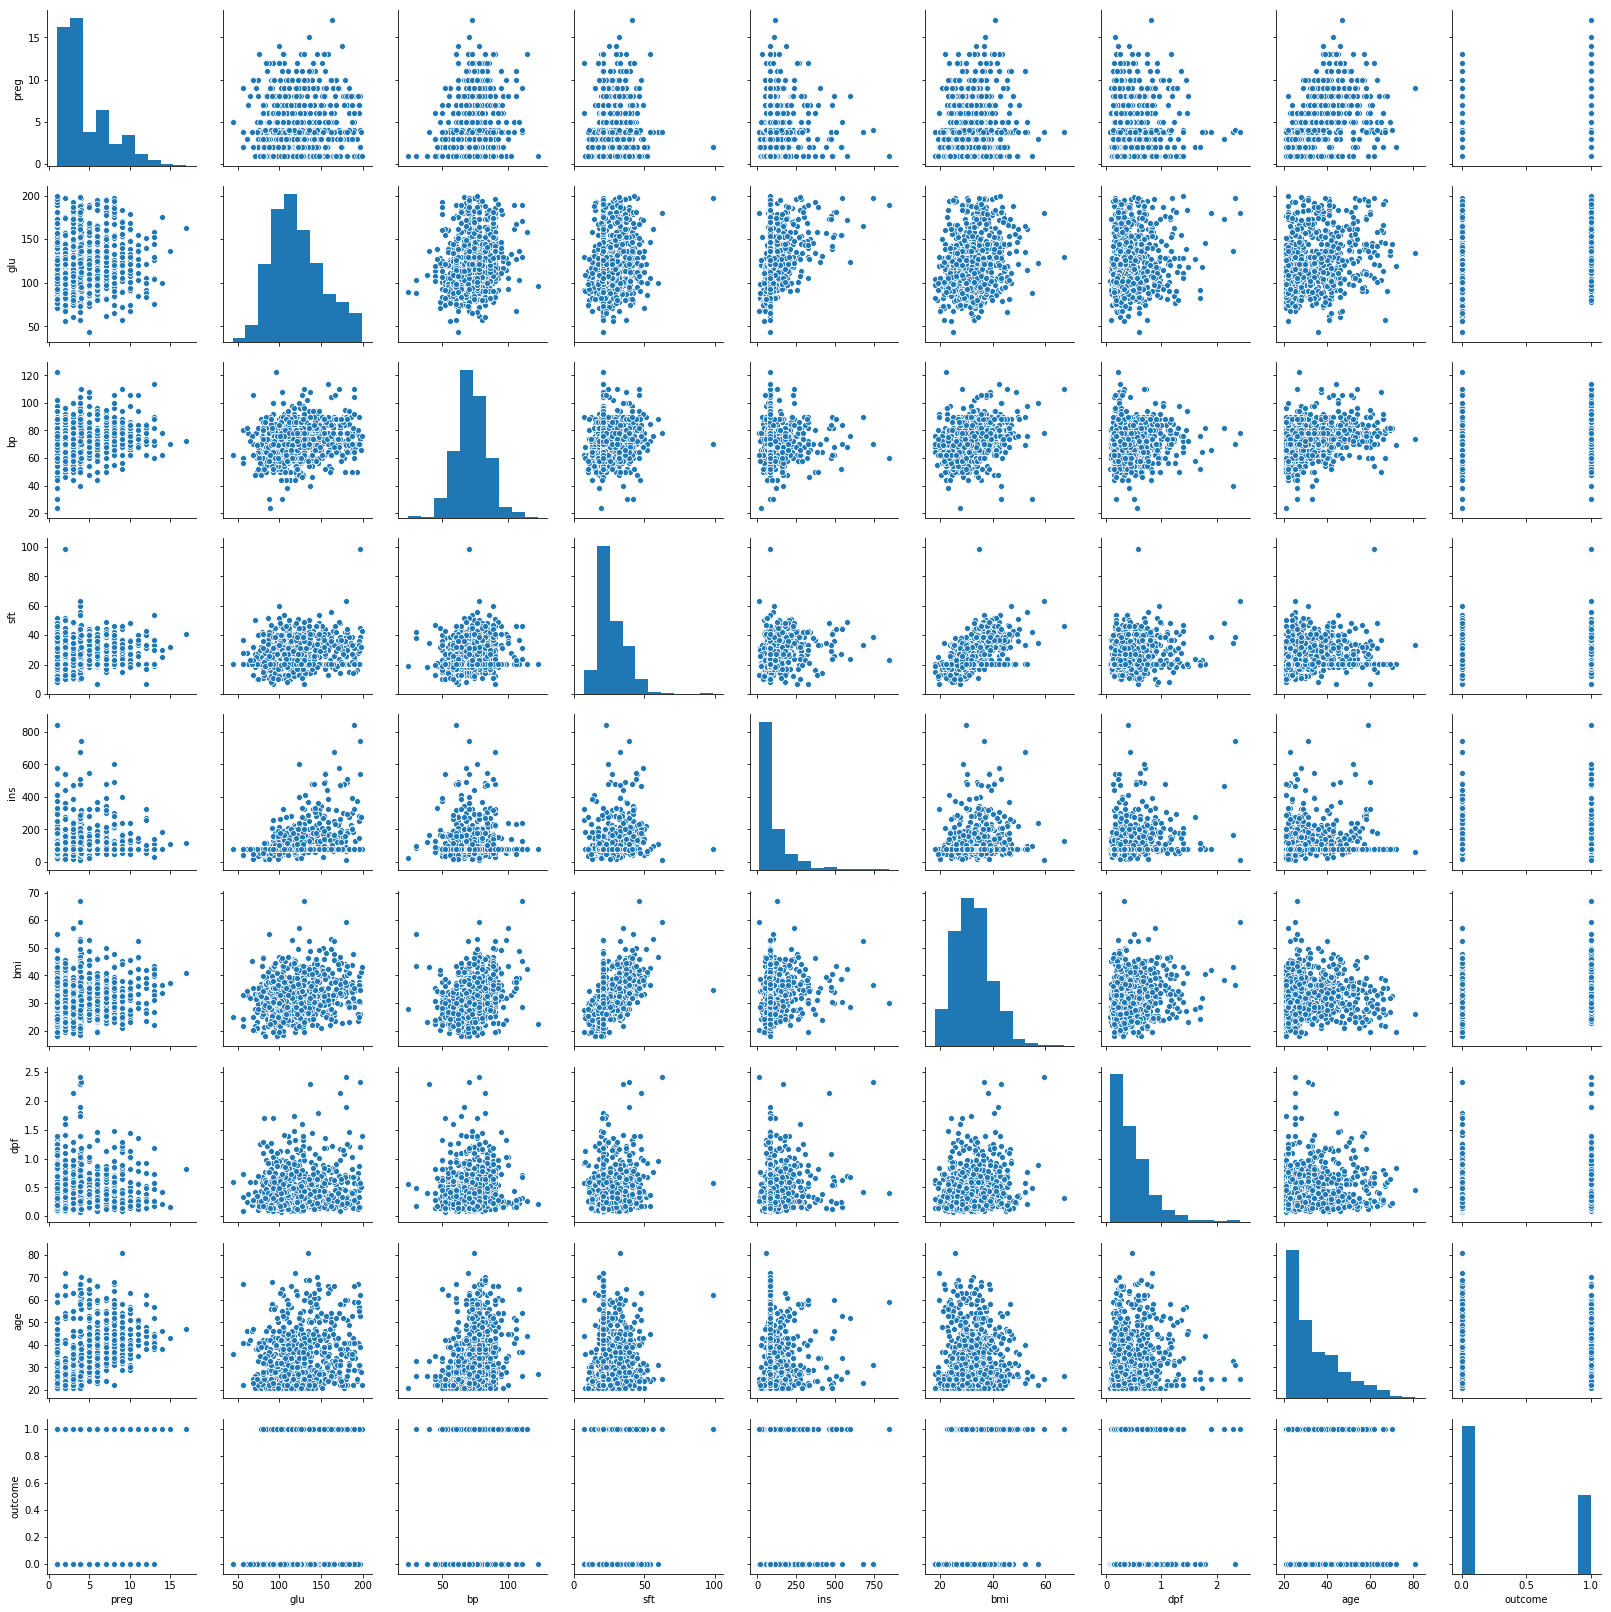

In [12]:
sns.pairplot(df)

In [13]:
df.corr()

,preg,glu,bp,sft,ins,bmi,dpf,age,outcome
preg,1.000000,0.152568,0.253275,0.045776,-0.016738,0.097663,-0.010297,0.525261,0.247971
glu,0.152568,1.000000,0.219666,0.160766,0.396597,0.231478,0.137106,0.266600,0.492908
bp,0.253275,0.219666,1.000000,0.134155,0.010926,0.281231,0.000371,0.326740,0.162986
sft,0.045776,0.160766,0.134155,1.000000,0.240361,0.535703,0.154961,0.026423,0.175026
ins,-0.016738,0.396597,0.010926,0.240361,1.000000,0.189856,0.157806,0.038652,0.179185
bmi,0.097663,0.231478,0.281231,0.535703,0.189856,1.000000,0.153508,0.025748,0.312254
dpf,-0.010297,0.137106,0.000371,0.154961,0.157806,0.153508,1.000000,0.033561,0.173844
age,0.525261,0.266600,0.326740,0.026423,0.038652,0.025748,0.033561,1.000000,0.238356
outcome,0.247971,0.492908,0.162986,0.175026,0.179185,0.312254,0.173844,0.238356,1.000000


## Observations
- 'glu' has the highest correlation with outcome
- 'bmi' has the second heighest correlation with outcome
- 'bp' has the lowest correlation with outcome
- Multicorrelation between features is low


# Q8 Split the pima_df into training and test set in the ratio of 70:30 (Training:Test).</b>


In [43]:
X = df.drop("outcome",axis=1)
y = df.outcome
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=7)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(537, 8) (537,) (231, 8) (231,)


# Q9 Create the decision tree model using “entropy” method of reducing the entropy and fit it to training data.</b>



In [44]:
from sklearn.tree import DecisionTreeClassifier

modelDT=DecisionTreeClassifier(criterion='entropy', random_state=0)

# Q10 Print the accuracy of the model & print the confusion matrix 

In [45]:
def evaluateModel(model, X_test, y_test, X_train, y_train):
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    acc=metrics.accuracy_score(y_test,y_pred)
    print("Accuracy =",acc)
    cm = metrics.confusion_matrix(y_test,y_pred)
    print("Confusion Matrix:\n", cm)

print("Decision Tree")
evaluateModel(modelDT, X_test, y_test, X_train, y_train)

Decision Tree
Accuracy = 0.7489177489177489
Confusion Matrix:
 [[117  30]
 [ 28  56]]


Print the feature importance of the decision model - Optional

In [17]:
print (pd.DataFrame(modelDT.feature_importances_, columns = ["Imp"], index = X_train.columns))

           Imp
preg  0.072307
glu   0.313185
bp    0.055744
sft   0.096141
ins   0.042216
bmi   0.174212
dpf   0.111822
age   0.134373


# Q12 Apply the Random forest model and print the accuracy of Random forest Model

In [46]:
from sklearn.ensemble import RandomForestClassifier
modelRf = RandomForestClassifier(n_estimators=51,criterion='entropy',random_state=0 )

In [19]:
evaluateModel(modelRf, X_test, y_test, X_train, y_train)

Accuracy = 0.7575757575757576
Confusion Matrix:
 [[122  25]
 [ 31  53]]


# Q13 Apply Adaboost Ensemble Algorithm for the same data and print the accuracy.

In [47]:
from sklearn.ensemble import AdaBoostClassifier
modelBoostRF = AdaBoostClassifier(base_estimator=modelRf,n_estimators=50,random_state=2)

In [48]:
evaluateModel(modelBoostRF, X_test, y_test, X_train, y_train)

Accuracy = 0.7835497835497836
Confusion Matrix:
 [[126  21]
 [ 29  55]]


# Q14 - Apply Bagging Classifier Algorithm and print the accuracy.

In [49]:
from sklearn.ensemble import BaggingClassifier

modelLR = LogisticRegression(random_state=2)
modelBaggingLR = BaggingClassifier(base_estimator=modelLR,n_estimators=20,random_state=2)

In [50]:
evaluateModel(modelBaggingLR, X_test, y_test, X_train, y_train)

Accuracy = 0.7922077922077922
Confusion Matrix:
 [[133  14]
 [ 34  50]]


# Q15 - Apply GradientBoost Classifier Algorithm for the same data and print the accuracy

In [51]:
from sklearn.ensemble import GradientBoostingClassifier
modelGB=GradientBoostingClassifier(n_estimators=20,random_state=2)

In [52]:
evaluateModel(modelGB, X_test, y_test, X_train, y_train)

Accuracy = 0.7705627705627706
Confusion Matrix:
 [[126  21]
 [ 32  52]]


# Next steps are optional and will not be graded.

Voting is one of the simplest ways of combining the predictions from multiple machine learning algorithms.

It works by first creating two or more standalone models from your training dataset. A Voting Classifier can then be used to wrap your models and average the predictions of the sub-models when asked to make predictions for new data.

Apply Voting Classfier on the given dataset and state your insights.

In [53]:
from sklearn.ensemble import VotingClassifier
stacked = VotingClassifier(estimators = [('Boosted_RF',modelBoostRF), ('Bagging_LR', modelBaggingLR), ('GradientBoost', modelGB)],voting='soft')

In [54]:
evaluateModel(stacked, X_test, y_test, X_train, y_train)

Accuracy = 0.7748917748917749
Confusion Matrix:
 [[128  19]
 [ 33  51]]
